inspiration : https://github.com/dportik/Pandas-for-Population-Structure-Barplots

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
# read in the population info file
pop_info_file = "albo_global_pops_UNSD.txt"

pop_table = pd.read_table(pop_info_file,sep='\t', header=None )
pop_table.index = pop_table[0]
pop_table.columns = ['indv','pop','native_invasive']
pop_table

,indv,pop,native_invasive
0,,,
ALKR1,ALKR1,Albania,invaded
ALKR3,ALKR3,Albania,invaded
ALKR4,ALKR4,Albania,invaded
ALKR5,ALKR5,Albania,invaded
ALSH2,ALSH2,Albania,invaded
...,...,...,...
vt18_17,vt18_17,Vietnam,native
vt18_18,vt18_18,Vietnam,native
vt18_19,vt18_19,Vietnam,native


In [4]:
Npop = 10


def read_Q_file( filename , Npop = None ):
    # read in the Q file, which is also whitespace delimited 
    # it contains K columns, one for each population,
    # each line correspond to the proportion of an individual
    df_q = pd.read_csv( filename, sep = ' ', header=None)

    if Npop is None:
        Npop = df_q.shape[1]
    
    df_q.index = id_list # row names <- sample ids

    df_q.columns = ["pop{}".format(i+1) for i in range(Npop)] # pop1 pop2 pop3 ...

    return df_q


def sort_df_by_pops(df , group_column , group_levels , npop ):
    
    temp_dfs = []
    for pop in group_levels:
        temp = df.loc[df[group_column] == pop].sort_values(by=[ f'pop{i+1}' for i in range(npop)  ], ascending=True)
        temp_dfs.append(temp)
    return pd.concat( temp_dfs )

In [12]:

def ADMIXTURE_barplot( df_q , Npop, group_column, group_levels , name_column  ):
    ## getting where the separation between populations should be 
    Ns = df_q_sorted[group_column].value_counts().to_dict()
    c = 0
    separators = []
    for l in group_levels[:-1]:
        c += Ns[l]
        separators.append(c-0.5)

    ax = df_q.plot.bar(stacked=True, 
                        figsize=(45,5), 
                        width=1,
                        color=sns.color_palette("tab20", Npop  ), 
                        fontsize='x-small',
                        edgecolor='black', 
                        linewidth=0.0,
                        legend=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticklabels( df_q[name_column], 
                       rotation=45, 
                       ha='right')
    #ax.legend(bbox_to_anchor=(1,1), fontsize='medium', labelspacing=0.5, frameon=False)
    ax.vlines( separators , 0,1 , color = 'black')
    return ax


In [13]:
## getting list of the sample ids used in the analysis from the fam file
id_list = pd.read_csv("094_admixture_all_no_indonesia/FM_0.70_mD_2_MD_30_FMi_0.35_LD_thin.siblings_removed.no_indonesia.fam" , sep = ' ', header=None).iloc[:,0]
simplify_label = lambda x : x[ :len( x )//2]
id_list = id_list.apply(simplify_label)

CPU times: user 1min 14s, sys: 7.11 s, total: 1min 22s
Wall time: 1min 13s


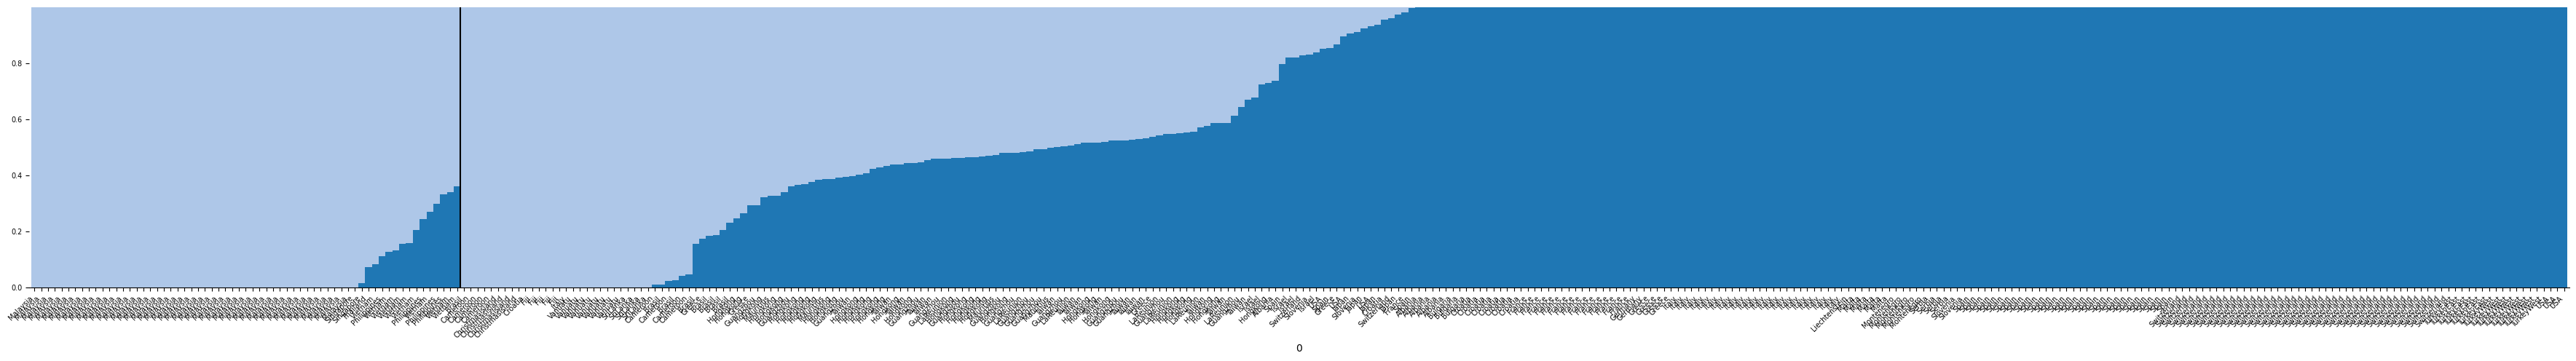

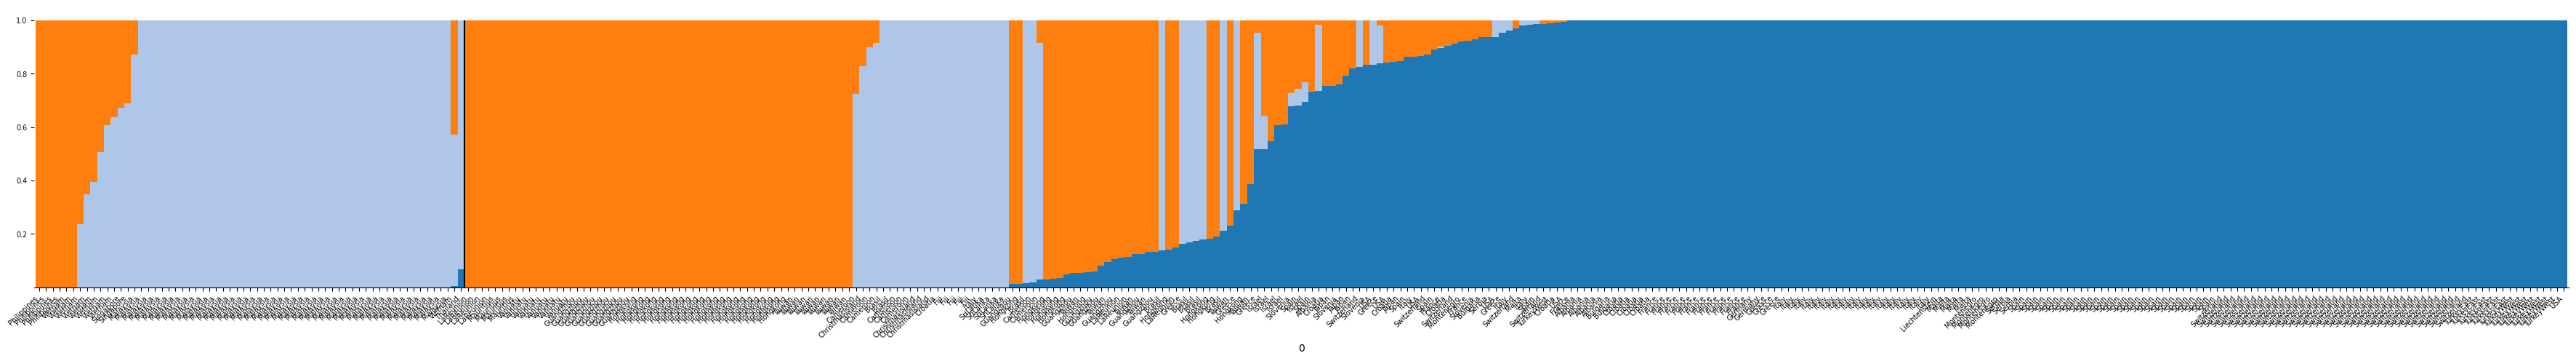

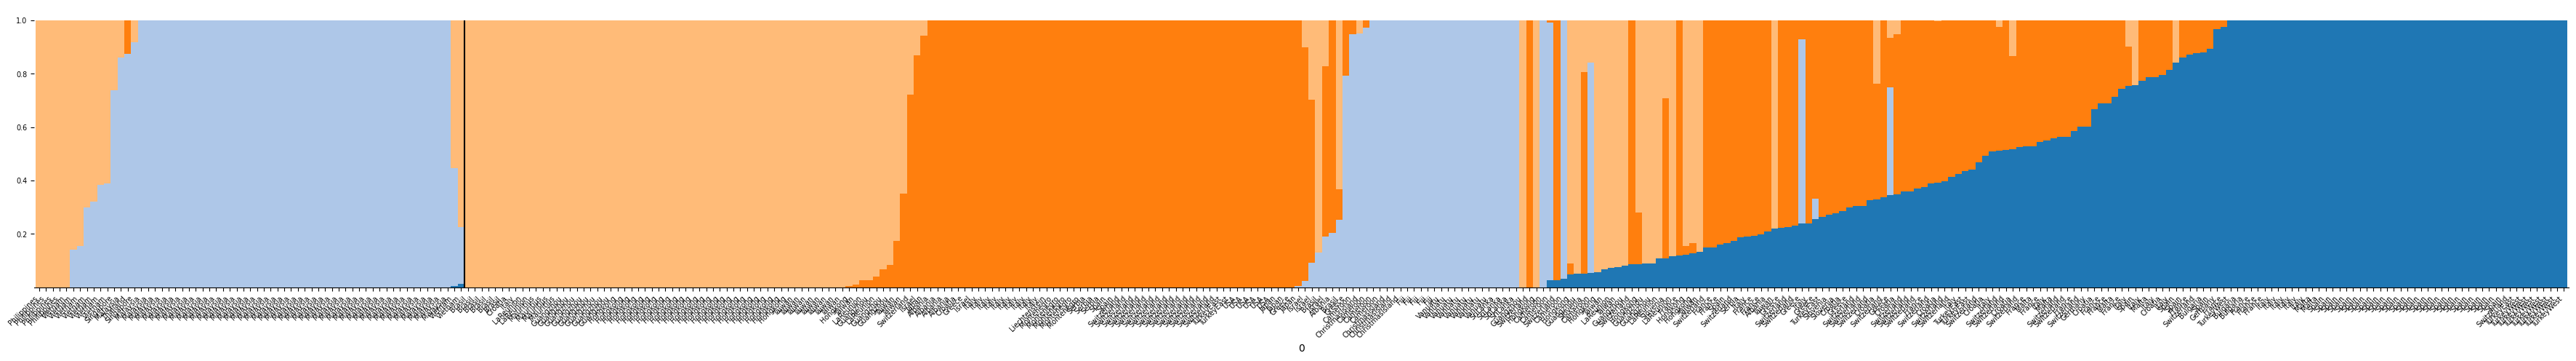

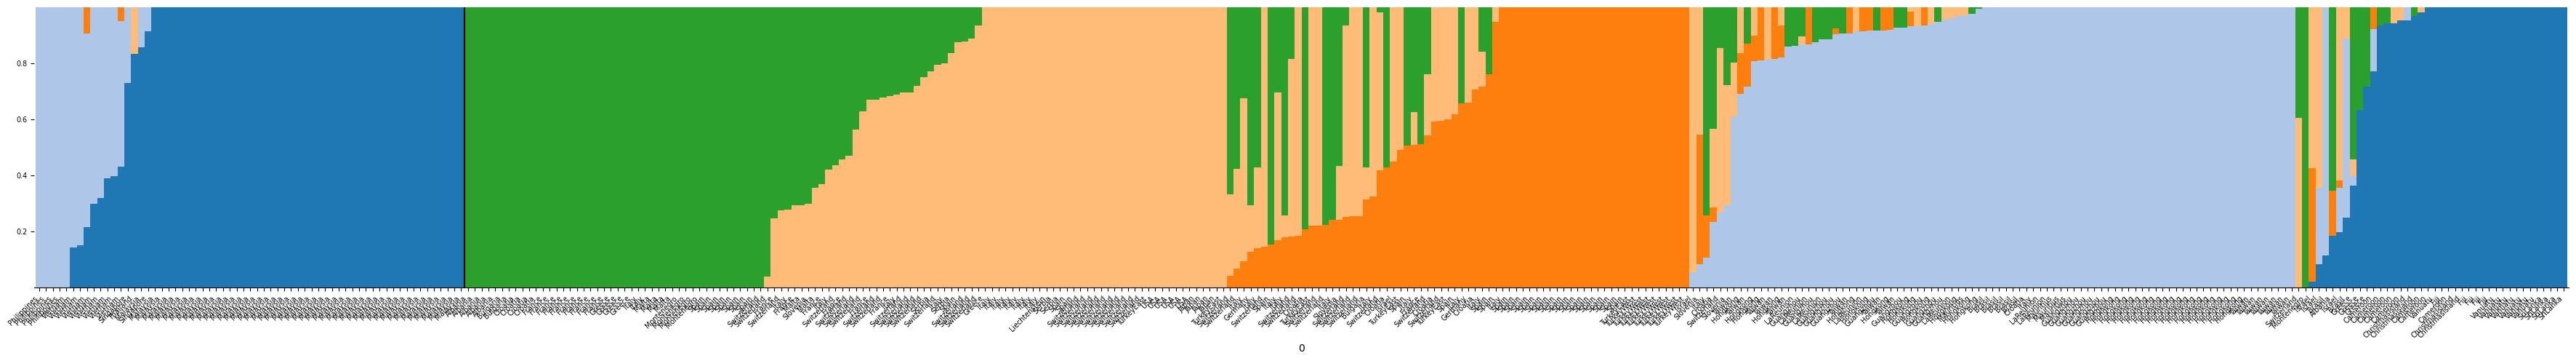

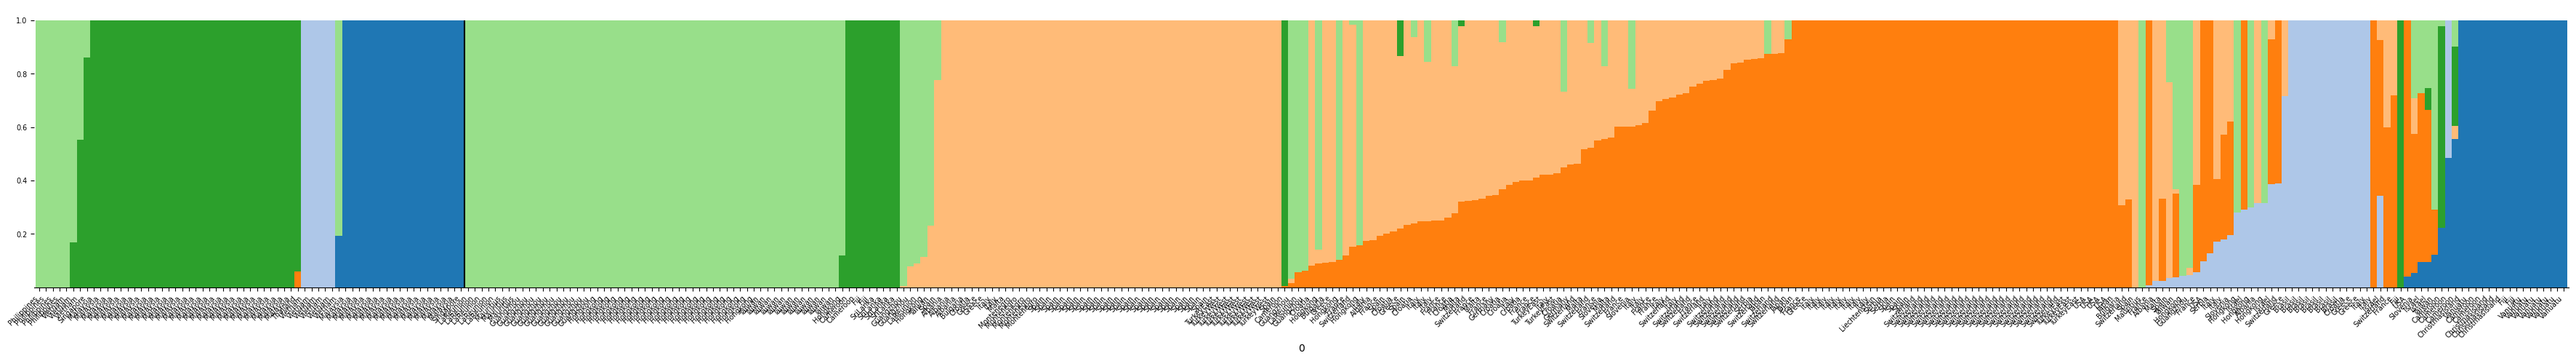

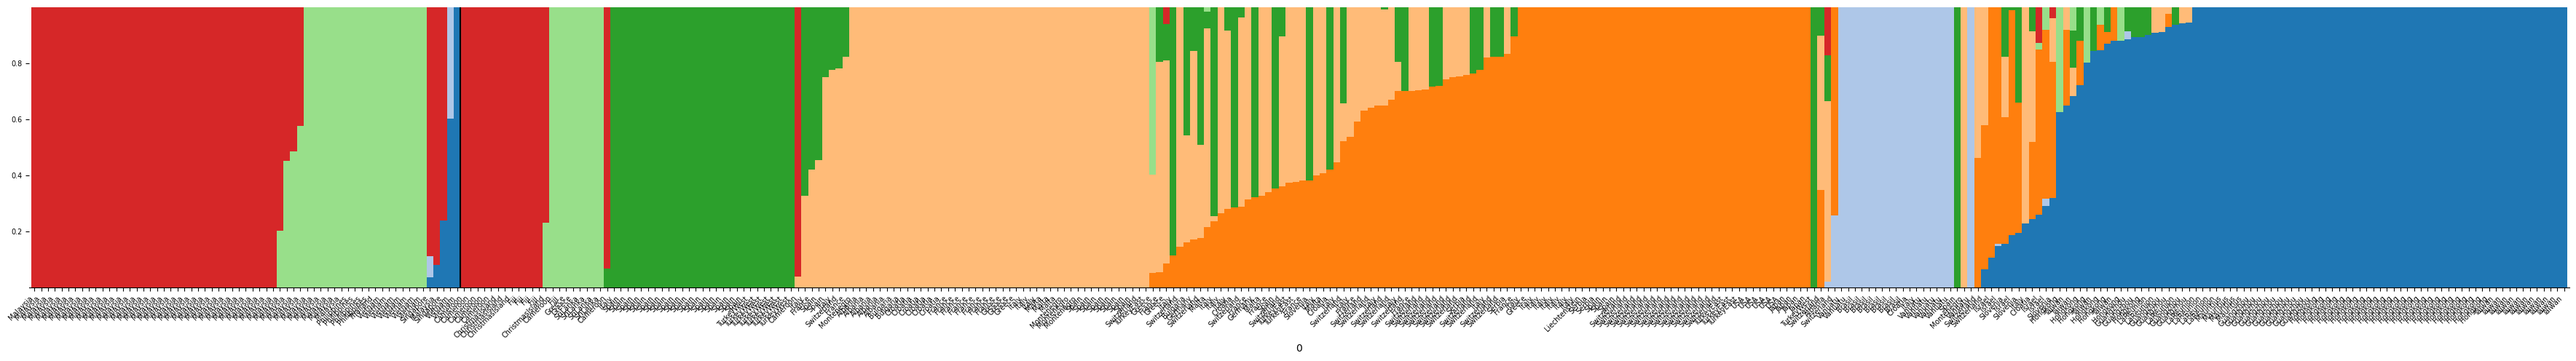

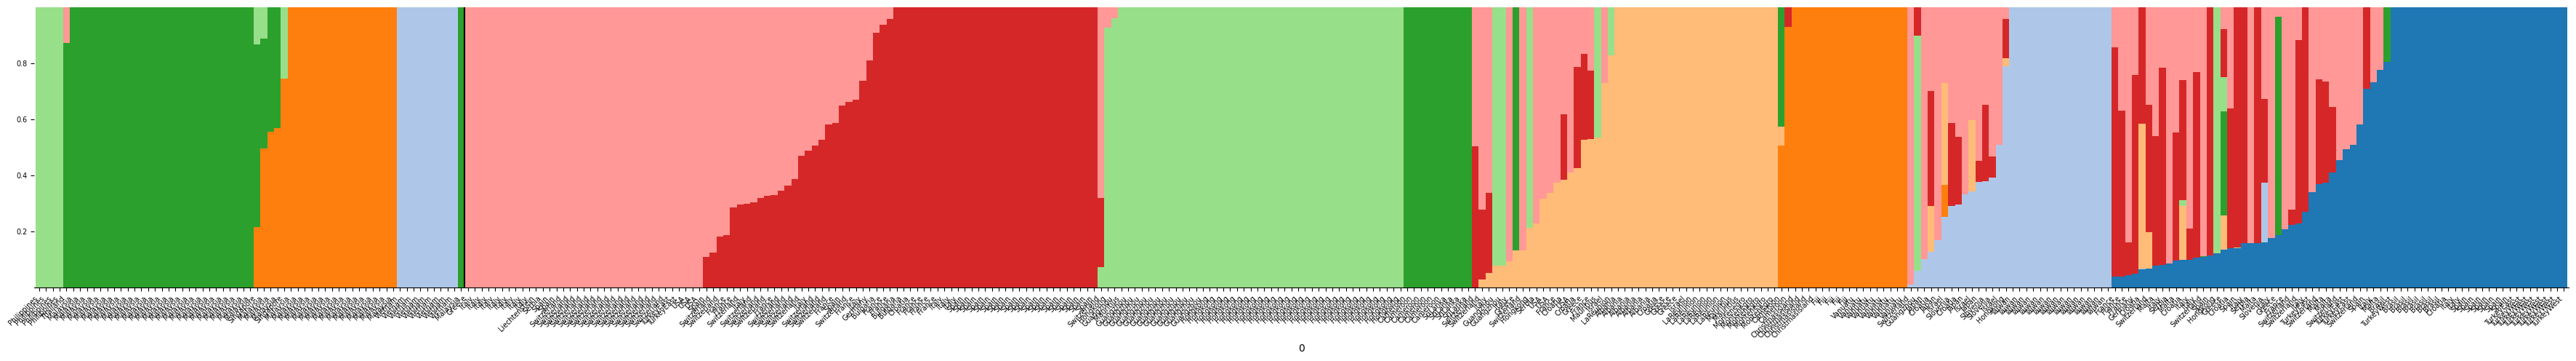

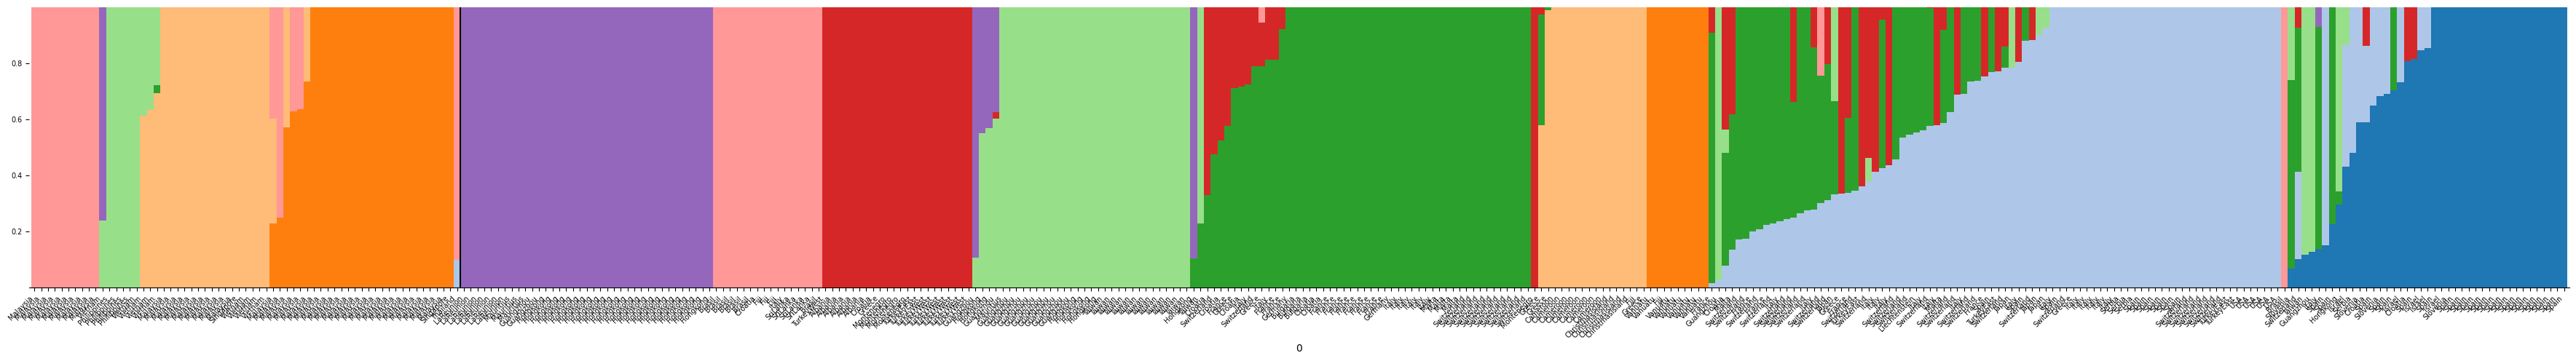

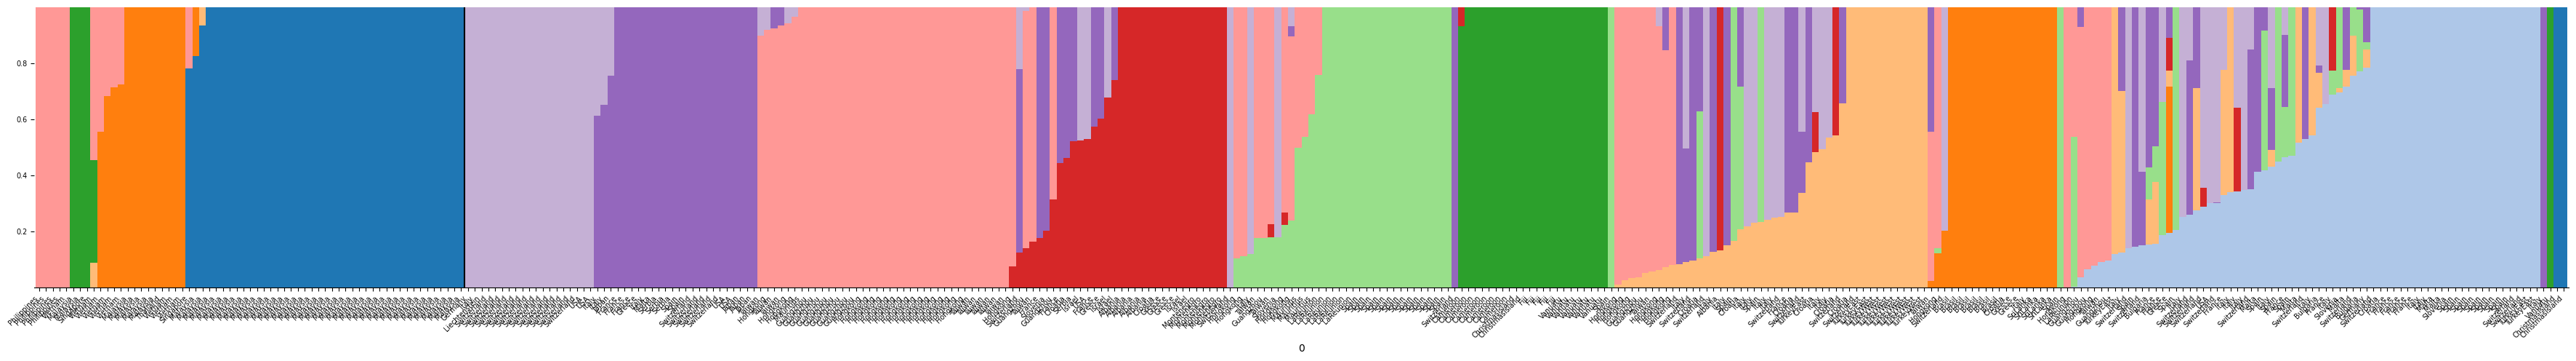

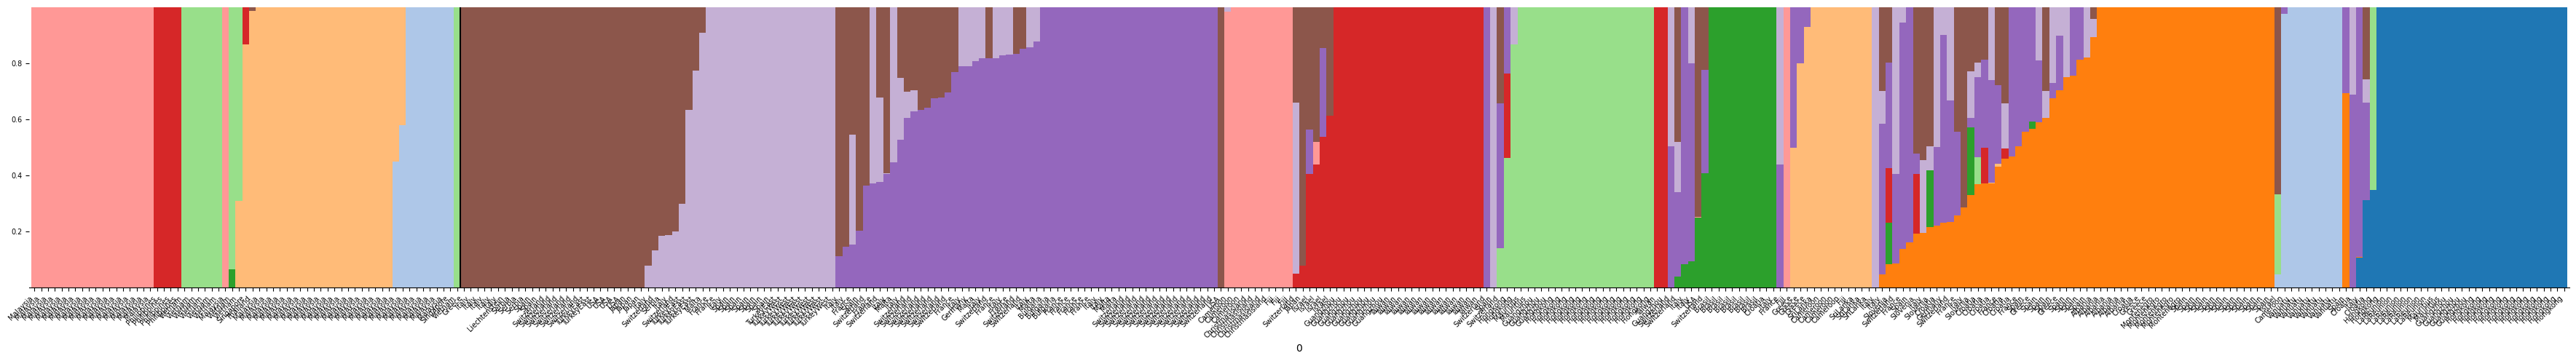

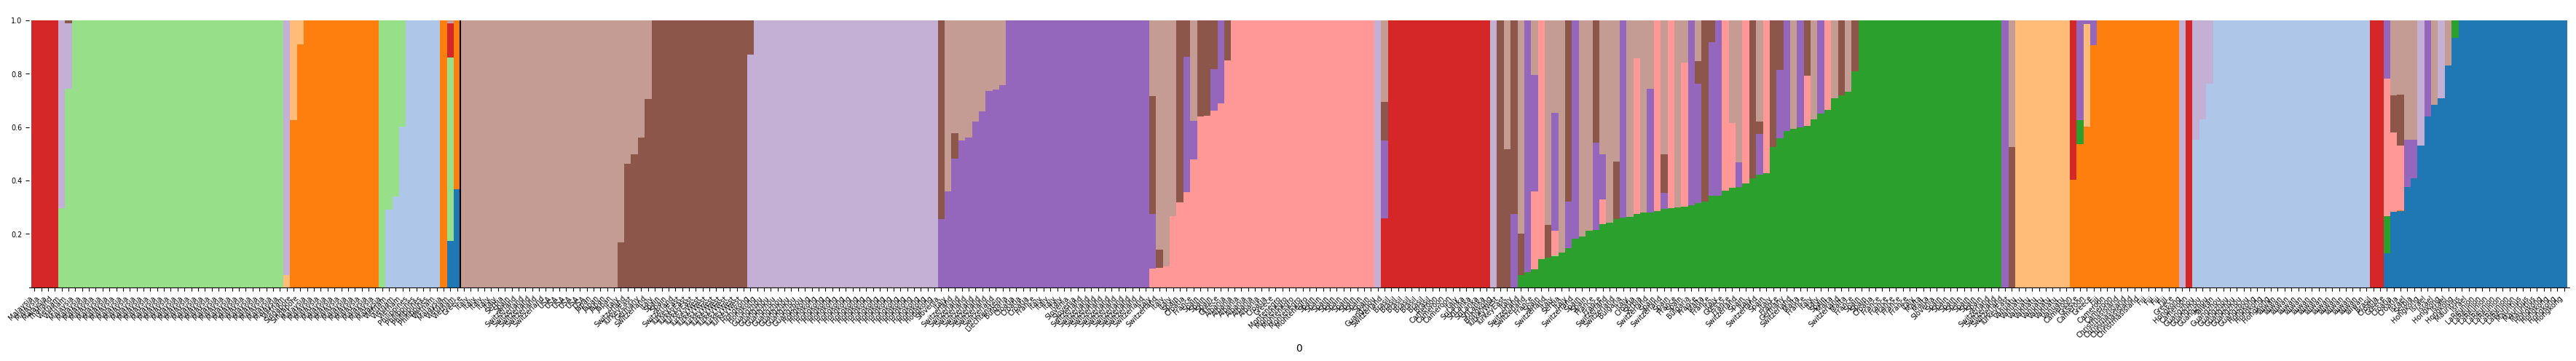

In [14]:
%%time
folder = '094_admixture_all_no_indonesia'

group_column = "assignment"
group_levels = [ 'native' , 'invaded' ]
for Npop in range(2,13):
    filename = f"{folder}/FM_0.70_mD_2_MD_30_FMi_0.35_LD_thin.siblings_removed.no_indonesia.{Npop}.Q"
    df_q = read_Q_file( filename , Npop = Npop )

    # Next we want to assign each individual to a population
    # There are several way of doing that:

    #   * based on highest proportion of ancestry.
    #df_q['assignment'] = df_q.idxmax(axis=1)

    #   * based on predefined information
    df_q['assignment'] = pop_table.loc[ df_q.index , 'native_invasive']
    df_q['country'] = pop_table.loc[ df_q.index , 'pop']


    # sorting

    ## simple
    # df_q_sorted = df_q.sort_values(by=['assignment']+[ f'pop{i+1}' for i in range(npop)  ] , ascending=True)
    ## more complex: control which levels are shown and in which order
    df_q_sorted = sort_df_by_pops(df_q , 
                                  group_column = group_column,
                                  group_levels = group_levels,
                                  npop = Npop )

    ax = ADMIXTURE_barplot( df_q_sorted , Npop, group_column, group_levels , name_column= "country"  )

    ax.figure.savefig(f'{folder}/ADMIXTURE_barplot.all.{Npop}.pdf', bbox_inches='tight')


CPU times: user 19.2 s, sys: 6.86 s, total: 26.1 s
Wall time: 18.4 s


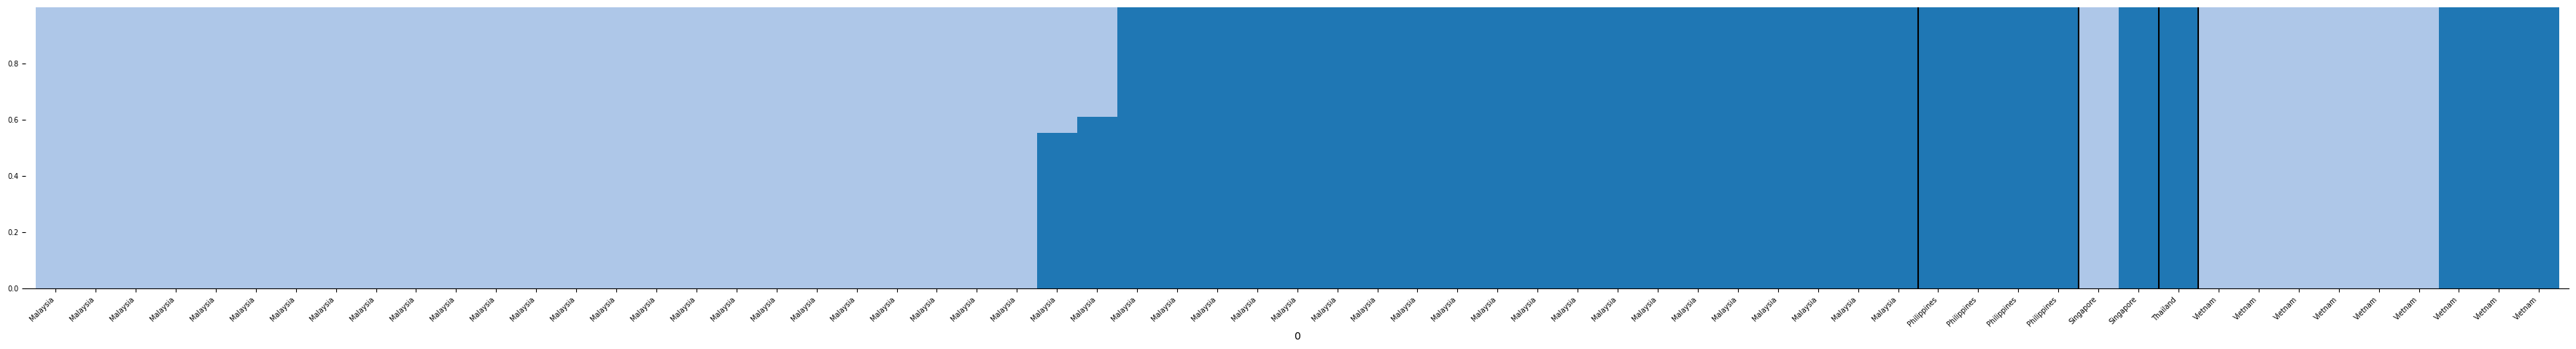

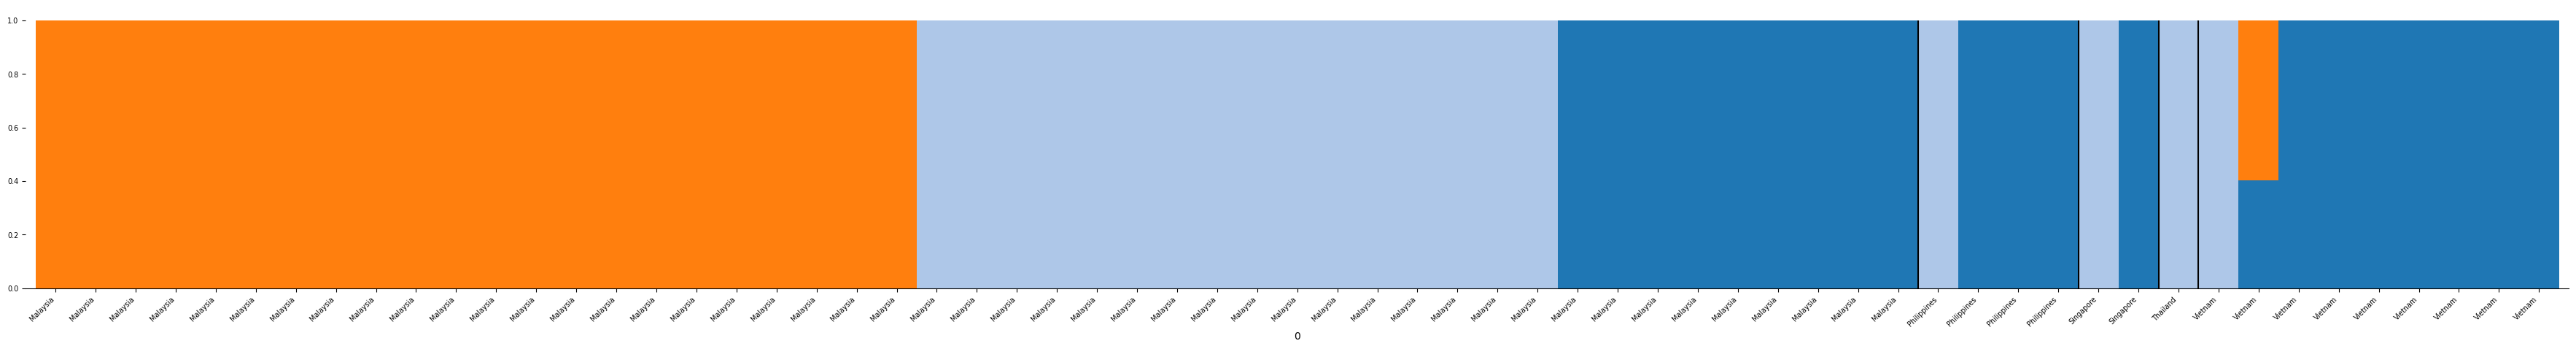

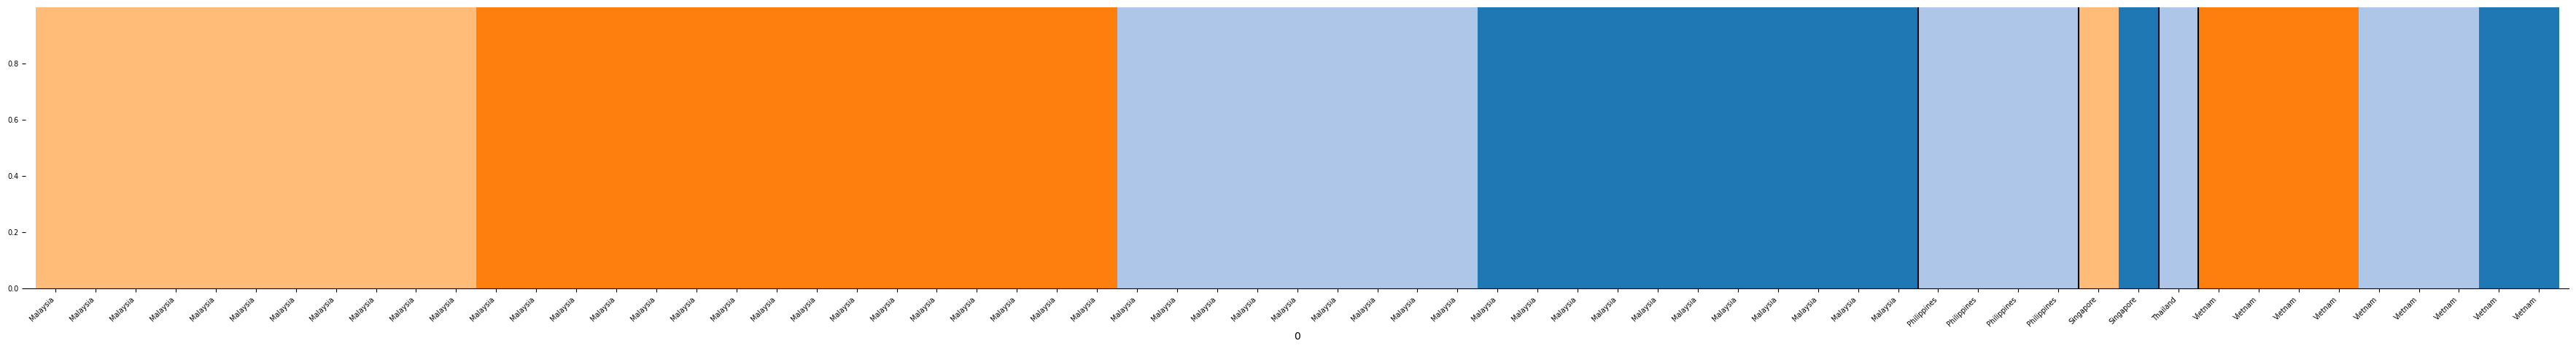

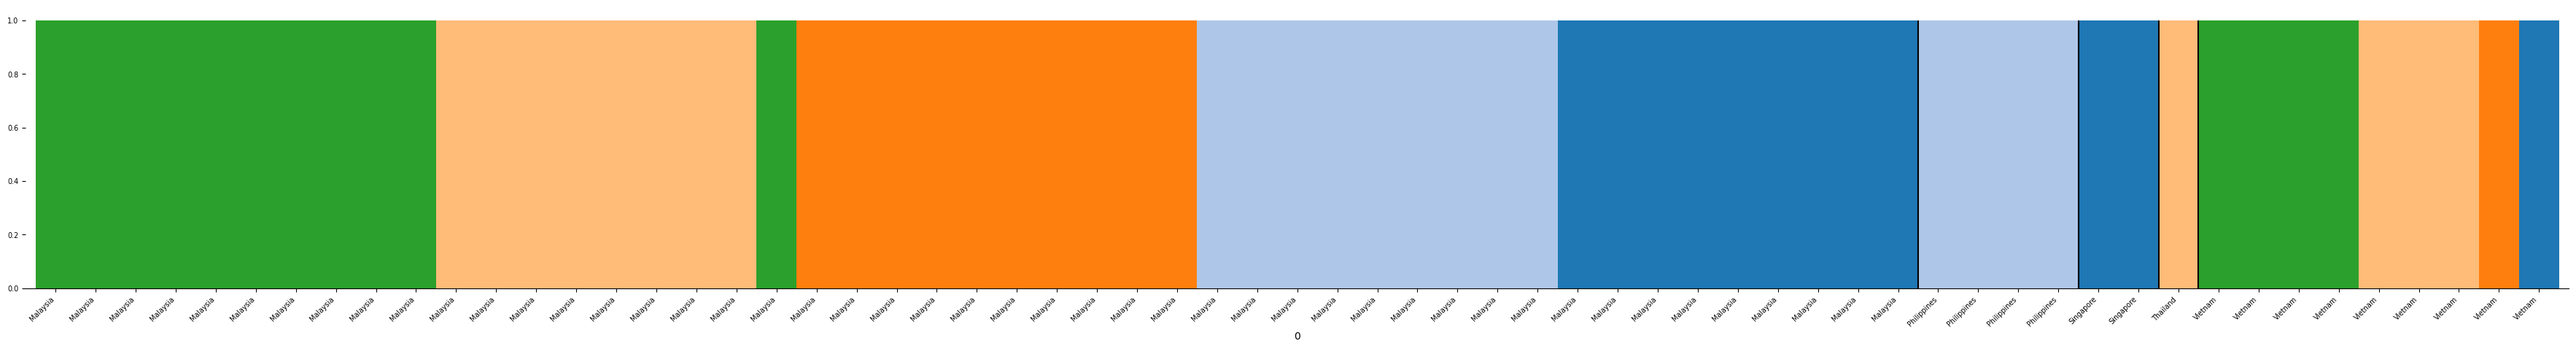

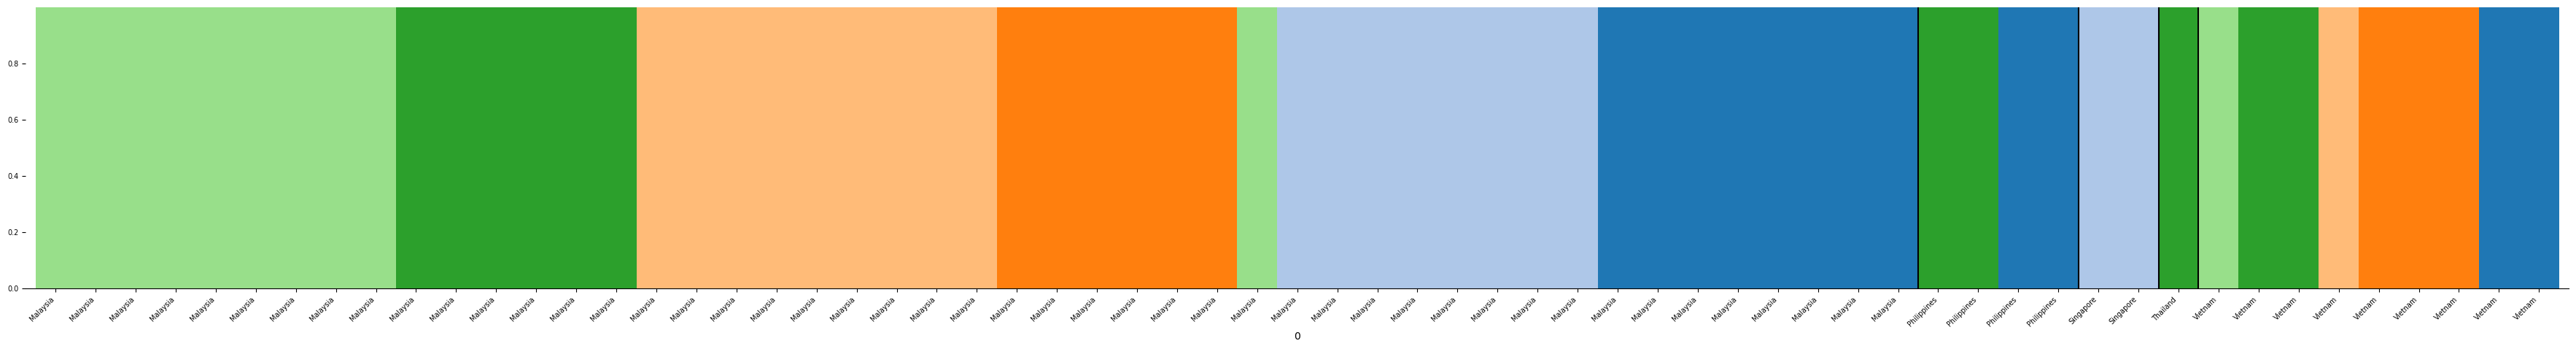

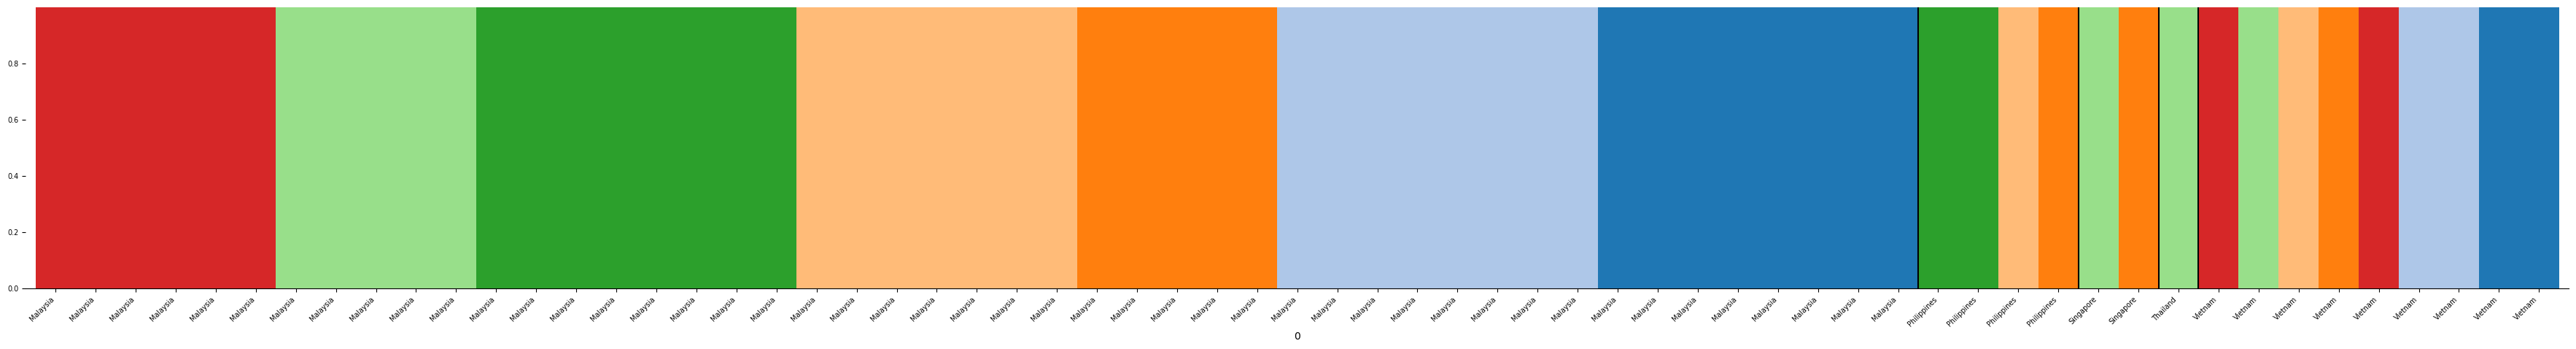

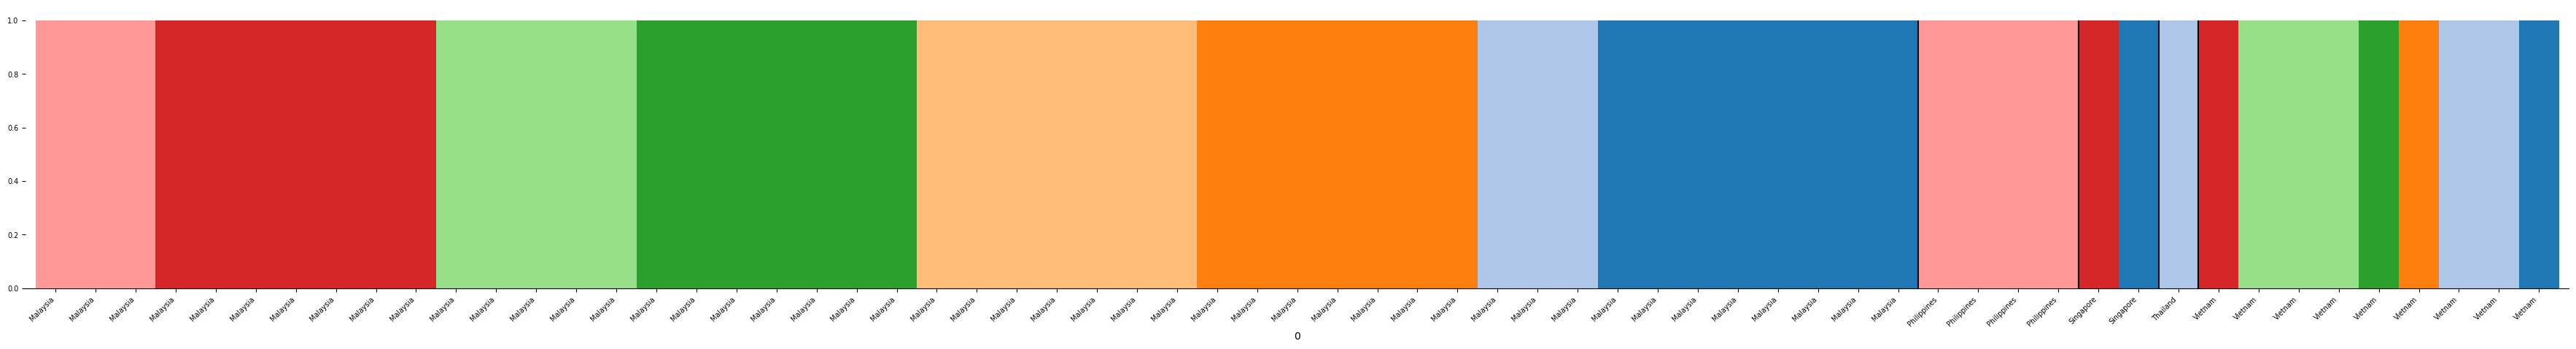

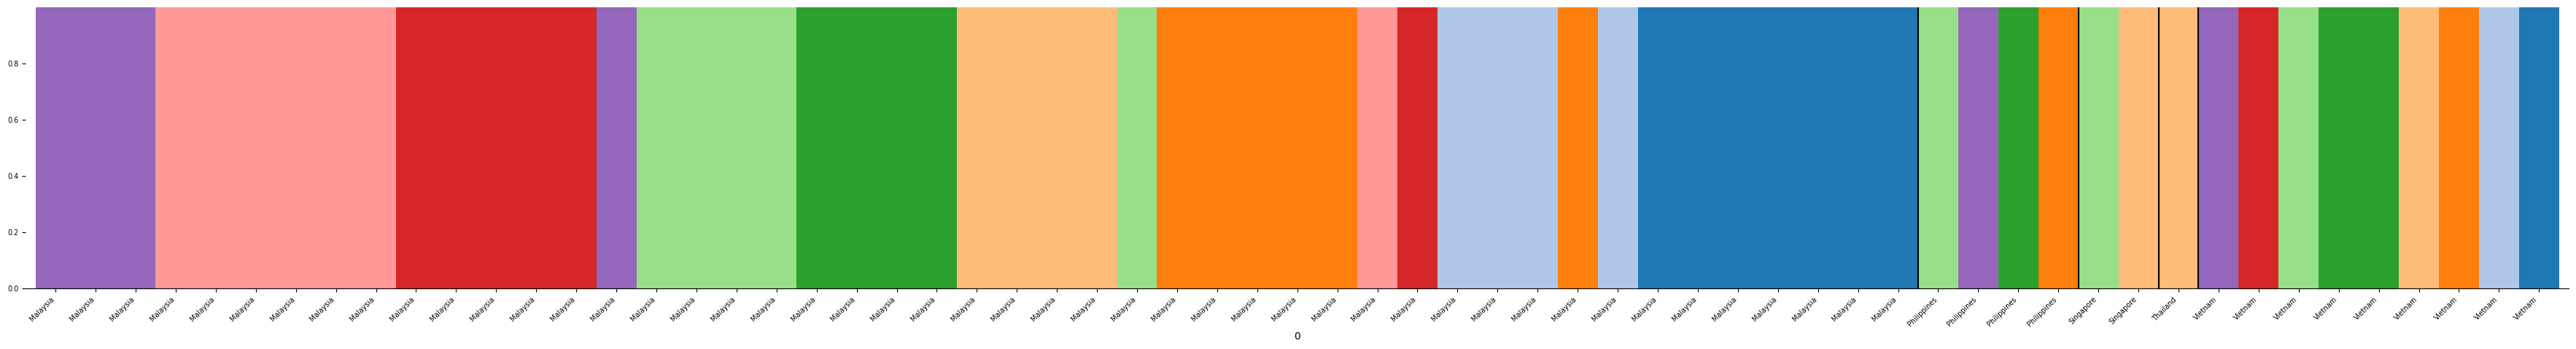

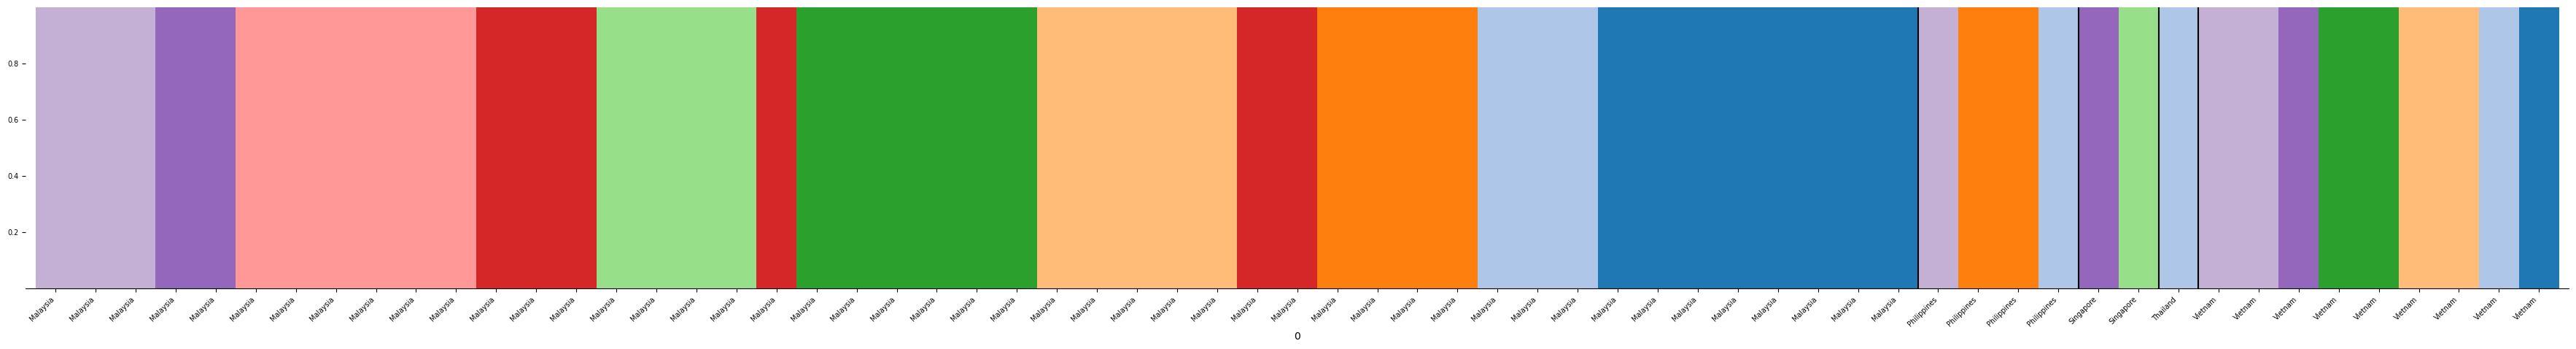

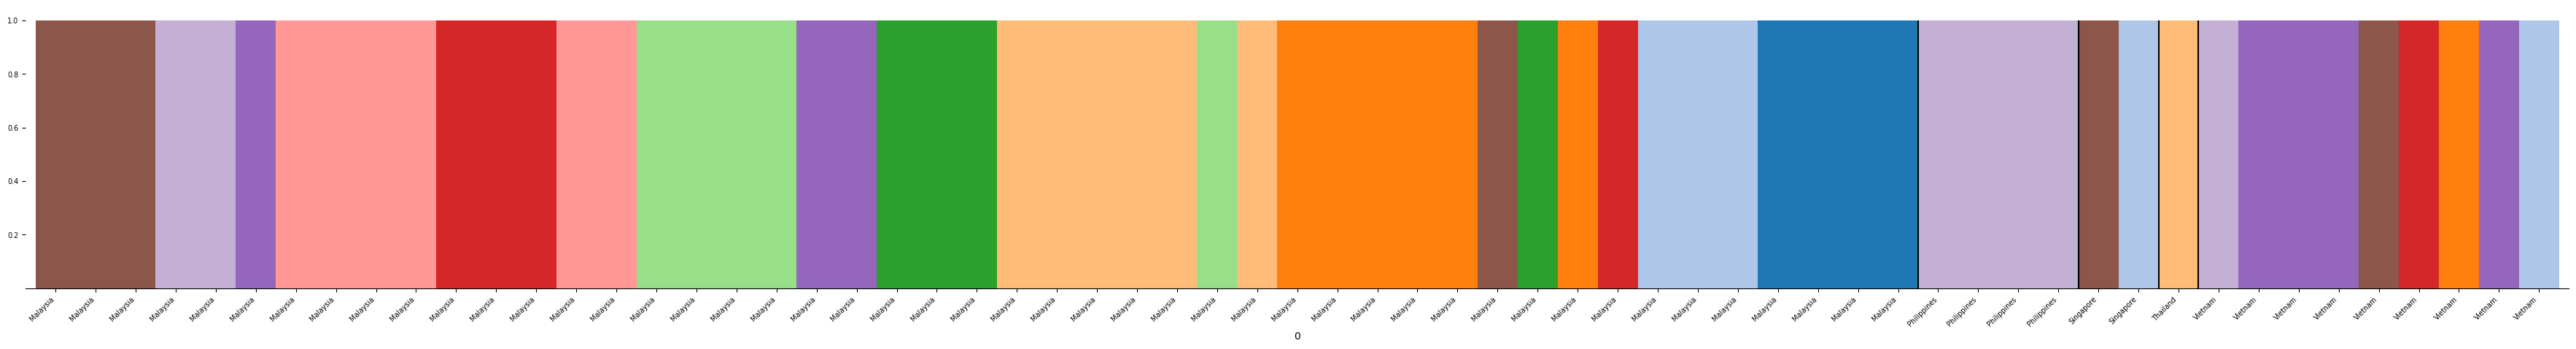

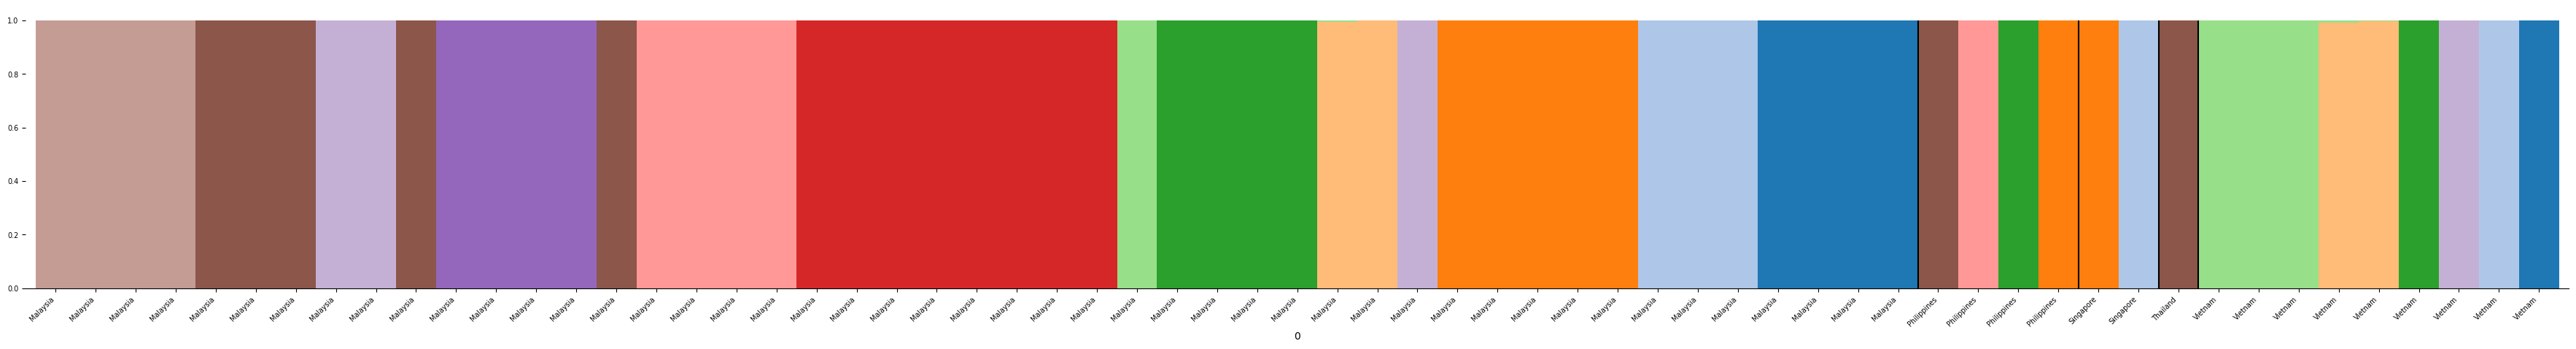

In [15]:
%%time

folder = '095_admixture_native_no_indonesia'
file_prefix = "FM_0.70_mD_2_MD_30_FMi_0.35_LD_thin.siblings_removed.no_indonesia.native"

## getting list of the sample ids used in the analysis from the fam file
id_list = pd.read_csv(f"{folder}/{file_prefix}.fam" , sep = ' ', header=None).iloc[:,0]
simplify_label = lambda x : x[ :len( x )//2]
id_list = id_list.apply(simplify_label)

group_column = "assignment"
group_levels = pop_table.loc[ id_list , 'pop'].unique()

for Npop in range(2,13):
    filename = f"{folder}/{file_prefix}.{Npop}.Q"
    df_q = read_Q_file( filename , Npop = Npop )

    # Next we want to assign each individual to a population
    # There are several way of doing that:

    #   * based on highest proportion of ancestry.
    #df_q['assignment'] = df_q.idxmax(axis=1)

    #   * based on predefined information
    #df_q['assignment'] = pop_table.loc[ df_q.index , 'native_invasive']
    df_q['assignment'] = pop_table.loc[ df_q.index , 'pop']
    df_q['name'] = df_q.index 


    # sorting

    ## simple
    # df_q_sorted = df_q.sort_values(by=['assignment']+[ f'pop{i+1}' for i in range(npop)  ] , ascending=True)
    ## more complex: control which levels are shown and in which order
    df_q_sorted = sort_df_by_pops(df_q , 
                                  group_column = group_column,
                                  group_levels = group_levels,
                                  npop = Npop )

    ax = ADMIXTURE_barplot( df_q_sorted , Npop, group_column, group_levels , name_column= "assignment"  )

    ax.figure.savefig(f'{folder}/ADMIXTURE_barplot.native.{Npop}.pdf', bbox_inches='tight')
